# Techniki interpretowalności modeli: implementacja metod wyjaśniania decyzji modeli uczenia maszynowego w medycynie

In [ ]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    mean_squared_error,
    r2_score,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [ ]:
PATH = "dane_pacjentow_demo.csv"
if os.path.exists(PATH):
    df = pd.read_csv(PATH)
else:
    N=600
    rng = np.random.default_rng(7)
    age = rng.integers(18, 90, size=N)
    sex = rng.choice(["F","M"], size=N)
    height = rng.normal(170, 10, size=N).clip(140, 200)
    weight = rng.normal(75, 15, size=N).clip(40, 160)
    bmi = weight / (height/100)**2
    sbp = (100 + 0.5*age + 1.2*bmi + (sex=="M")*5 + rng.normal(0,10,N)).round()
    dbp = (60 + 0.2*age + 0.6*bmi + (sex=="M")*3 + rng.normal(0,6,N)).round()
    glucose = rng.normal(105, 20, size=N).round().clip(60, 300)
    hypertension = ((sbp>=140)|(dbp>=90)).astype(int)
    df = pd.DataFrame(dict(age=age, sex=sex, bmi=bmi.round(1),
                           systolic_bp=sbp.astype(int),
                           diastolic_bp=dbp.astype(int),
                           glucose=glucose.astype(int),
                           hypertension=hypertension))

# 2) Klasyfikacja: przewidywanie nadciśnienia
features = ["age","sex","bmi","glucose","systolic_bp","diastolic_bp"]
X = df[features].copy(); y = df["hypertension"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

num = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat)
])

clf = Pipeline([("pre", pre),
                ("model", LogisticRegression(max_iter=1000))]).fit(X_train,y_train)

proba = clf.predict_proba(X_test)[:,1]
pred = (proba>=0.5).astype(int)
print("ACC:", accuracy_score(y_test,pred), "AUC:", roc_auc_score(y_test,proba))

ACC: 0.98 AUC: 0.9973739495798319


## Permutation Importance (globalna ważność cech)

        feature        PI
4   systolic_bp  0.086667
0           age  0.025333
1           sex  0.002667
5  diastolic_bp  0.001333
3       glucose -0.002000
2           bmi -0.002667


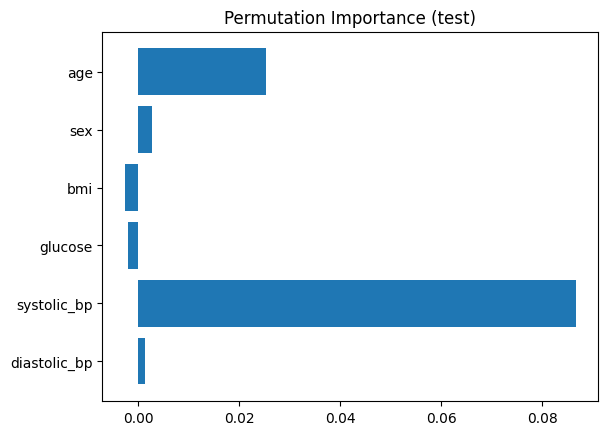

In [2]:
pi = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
imp = pd.DataFrame({"feature": X_test.columns, "PI": pi.importances_mean})
print(imp.sort_values("PI", ascending=False))

plt.figure(); plt.barh(imp["feature"], imp["PI"])
plt.title("Permutation Importance (test)"); plt.gca().invert_yaxis(); plt.show()

## PDP i ICE (zależności globalne/lokalne)

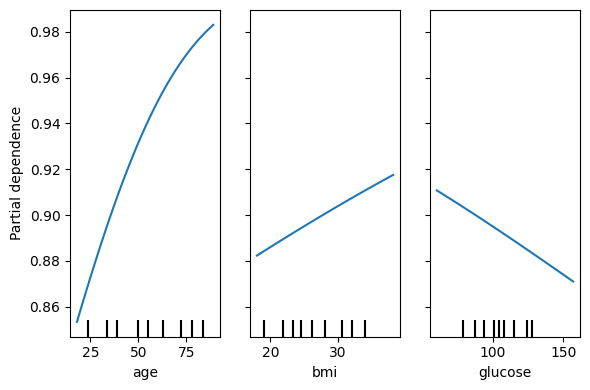

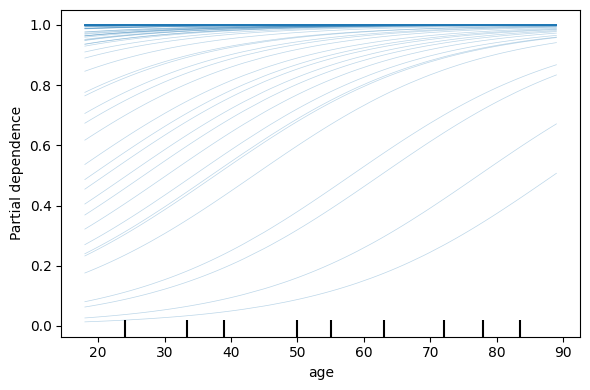

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
PartialDependenceDisplay.from_estimator(
    clf, X_test, features=["age","bmi","glucose"], kind="average", ax=ax)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6,4))
PartialDependenceDisplay.from_estimator(
    clf, X_test, features=["age"], kind="individual", subsample=100, ax=ax)
plt.tight_layout(); plt.show()

## SHAP (lokalne i globalne wyjaśnienia)

In [4]:
#!conda install -c conda-forge shap

In [5]:
try:
    import shap
    explainer = shap.LinearExplainer(clf.named_steps["model"],
                                     shap.sample(clf.named_steps["pre"].transform(X_train), 200),
                                     feature_names=list(X_train.columns))
    Xte = clf.named_steps["pre"].transform(X_test)
    sv = explainer.shap_values(Xte)
    shap.summary_plot(sv, features=X_test, feature_names=list(X_test.columns), show=False)
    plt.show()

    # Wyjaśnienie pojedynczej próbki
    i = 0
    shap.force_plot(explainer.expected_value, sv[i,:], X_test.iloc[i,:], matplotlib=True)
    plt.show()
except Exception as e:
    print("SHAP niedostępny lub błąd:", e)

SHAP niedostępny lub błąd: The shape of the shap_values matrix does not match the shape of the provided data matrix. Perhaps the extra column in the shap_values matrix is the constant offset? Of so just pass shap_values[:,:-1].


## LIME (wersja tekstowa wyjaśnień lokalnych)

In [6]:
! pip install lime

^C


In [ ]:
try:
    from lime.lime_tabular import LimeTabularExplainer

    # 1. Bierzemy tylko cechy numeryczne do LIME
    num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
    X_train_num = X_train[num_cols].to_numpy()
    X_test_num  = X_test[num_cols].to_numpy()

    print("Cechy numeryczne używane przez LIME:", num_cols)

    explainer = LimeTabularExplainer(
        training_data=X_train_num,
        feature_names=num_cols,
        class_names=["noHT", "HT"],
        discretize_continuous=True,
        mode="classification"
    )

    # 2. Funkcja predykcji: dostaje NUMPY z cechami numerycznymi
    def make_predict_fn_for_patient(sex_value):
        """Zwraca funkcję predict_fn, która dokleja płeć pacjenta."""
        def predict_fn(x_num):
            # x_num: (n_samples, len(num_cols))
            X_df = pd.DataFrame(x_num, columns=num_cols)
            # dokładamy stałą płeć (ten sam sex dla wszystkich perturbacji)
            X_df["sex"] = sex_value
            # ewentualnie inne cechy kategoryczne podobnie
            return clf.predict_proba(X_df)
        return predict_fn

    # 3. Wybieramy pacjenta do wyjaśnienia
    i = 0  # np. pierwszy z testowych
    x0_num = X_test_num[i]
    sex0   = X_test.iloc[i]["sex"]   # płeć tego pacjenta

    predict_fn = make_predict_fn_for_patient(sex0)

    exp = explainer.explain_instance(
        data_row=x0_num,
        predict_fn=predict_fn,
        num_features=6,
        top_labels=1
    )

    print("Wyjaśnienie LIME dla pacjenta", i, "| sex =", sex0)
    for feat, val in exp.as_list(label=1):
        print(feat, "=>", val)

except Exception as e:
    print("LIME niedostępny lub błąd:", e)


In [ ]:
try:
    from lime.lime_tabular import LimeTabularExplainer

    # 1. Bierzemy tylko cechy numeryczne do LIME
    num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
    X_train_num = X_train[num_cols].to_numpy()
    X_test_num  = X_test[num_cols].to_numpy()

    print("Cechy numeryczne używane przez LIME:", num_cols)

    explainer = LimeTabularExplainer(
        training_data=X_train_num,
        feature_names=num_cols,
        class_names=["noHT", "HT"],
        discretize_continuous=True,
        mode="classification"
    )

    # 2. Funkcja predykcji: dostaje NUMPY z cechami numerycznymi
    def make_predict_fn_for_patient(sex_value):
        """Zwraca funkcję predict_fn, która dokleja płeć pacjenta."""
        def predict_fn(x_num):
            # x_num: (n_samples, len(num_cols))
            X_df = pd.DataFrame(x_num, columns=num_cols)
            # dokładamy stałą płeć (ten sam sex dla wszystkich perturbacji)
            X_df["sex"] = sex_value
            # ewentualnie inne cechy kategoryczne podobnie
            return clf.predict_proba(X_df)
        return predict_fn

    # 3. Wybieramy pacjenta do wyjaśnienia
    i = 0  # np. pierwszy z testowych
    x0_num = X_test_num[i]
    sex0   = X_test.iloc[i]["sex"]   # płeć tego pacjenta

    predict_fn = make_predict_fn_for_patient(sex0)

    exp = explainer.explain_instance(
        data_row=x0_num,
        predict_fn=predict_fn,
        num_features=6,
        top_labels=1
    )

    print("Wyjaśnienie LIME dla pacjenta", i, "| sex =", sex0)
    for feat, val in exp.as_list(label=1):
        print(feat, "=>", val)

except Exception as e:
    print("LIME niedostępny lub błąd:", e)


In [ ]:
try:
    from lime.lime_tabular import LimeTabularExplainer

    # 1. Bierzemy tylko cechy numeryczne do LIME
    num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
    X_train_num = X_train[num_cols].to_numpy()
    X_test_num  = X_test[num_cols].to_numpy()

    print("Cechy numeryczne używane przez LIME:", num_cols)

    explainer = LimeTabularExplainer(
        training_data=X_train_num,
        feature_names=num_cols,
        class_names=["noHT", "HT"],
        discretize_continuous=True,
        mode="classification"
    )

    # 2. Funkcja predykcji: dostaje NUMPY z cechami numerycznymi
    def make_predict_fn_for_patient(sex_value):
        """Zwraca funkcję predict_fn, która dokleja płeć pacjenta."""
        def predict_fn(x_num):
            # x_num: (n_samples, len(num_cols))
            X_df = pd.DataFrame(x_num, columns=num_cols)
            # dokładamy stałą płeć (ten sam sex dla wszystkich perturbacji)
            X_df["sex"] = sex_value
            # ewentualnie inne cechy kategoryczne podobnie
            return clf.predict_proba(X_df)
        return predict_fn

    # 3. Wybieramy pacjenta do wyjaśnienia
    i = 0  # np. pierwszy z testowych
    x0_num = X_test_num[i]
    sex0   = X_test.iloc[i]["sex"]   # płeć tego pacjenta

    predict_fn = make_predict_fn_for_patient(sex0)

    exp = explainer.explain_instance(
        data_row=x0_num,
        predict_fn=predict_fn,
        num_features=6,
        top_labels=1
    )

    print("Wyjaśnienie LIME dla pacjenta", i, "| sex =", sex0)
    for feat, val in exp.as_list(label=1):
        print(feat, "=>", val)

except Exception as e:
    print("LIME niedostępny lub błąd:", e)


## Krzywe ROC oraz macierz pomyłek (kontekst kliniczny)

In [ ]:
fpr, tpr, thr = roc_curve(y_test, proba)
plt.figure(); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC"); plt.show()

cm = confusion_matrix(y_test, pred)
plt.figure(); plt.imshow(cm); plt.title("Confusion matrix"); plt.colorbar()
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    plt.text(j,i,str(cm[i,j]), ha="center", va="center")
plt.xticks([0,1],["neg","pos"]); plt.yticks([0,1],["neg","pos"])
plt.tight_layout(); plt.show()